# 25 DMOs -> fatigue

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.train.train_regression_xv import LSTMRegressionXV
from src.core.data_transforms import Transform


import torch

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=25,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [ ]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [9]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [10]:
dmo_data = dmo_data.mean(axis=2)

In [11]:
dmo_labels.shape

torch.Size([428, 4, 1])

In [12]:
# Min max normalise the labels globally

label_normaliser = Normaliser(MinMaxScaler())
dmo_labels = label_normaliser.scaler_fit_transform(dmo_labels)

In [13]:
dmo_data = dmo_data.flatten(start_dim=0, end_dim=1)
dmo_data = dmo_data.unsqueeze(1)
dmo_labels = dmo_labels.flatten(start_dim=0, end_dim=1)
dmo_labels = dmo_labels.unsqueeze(dim=1)
print(dmo_data.shape)
print(dmo_labels.shape)

torch.Size([1712, 1, 25])
torch.Size([1712, 1, 1])


In [14]:
xv_trainer = LSTMRegressionXV(dmo_data, dmo_labels, config, device, k=K_FOLDS)
prediction, actual = xv_trainer.train_cross_validation()

Testing loss: 0.04958655642853542
<class 'list'>
[tensor([[0.6803]]), tensor([[0.4687]]), tensor([[0.5776]]), tensor([[0.6506]]), tensor([[0.6231]]), tensor([[0.7744]]), tensor([[0.2511]]), tensor([[0.6058]]), tensor([[0.6326]]), tensor([[0.5930]]), tensor([[0.5303]]), tensor([[0.8073]]), tensor([[0.4451]]), tensor([[0.5386]]), tensor([[0.5787]]), tensor([[0.6546]]), tensor([[0.3922]]), tensor([[0.4242]]), tensor([[0.5116]]), tensor([[0.5382]]), tensor([[0.5286]]), tensor([[0.3307]]), tensor([[0.5706]]), tensor([[0.3833]]), tensor([[0.8152]]), tensor([[0.7255]]), tensor([[0.4389]]), tensor([[0.6310]]), tensor([[0.5741]]), tensor([[0.6658]]), tensor([[0.4182]]), tensor([[0.5440]]), tensor([[0.4877]]), tensor([[0.5605]]), tensor([[0.3168]]), tensor([[0.5088]]), tensor([[0.4441]]), tensor([[0.5293]]), tensor([[0.6224]]), tensor([[0.4240]]), tensor([[0.5639]]), tensor([[0.6308]]), tensor([[0.5818]]), tensor([[0.6073]]), tensor([[0.5508]]), tensor([[0.5812]]), tensor([[0.6815]]), tensor([[0

In [15]:
prediction

[tensor([0.6803, 0.4687, 0.5776, 0.6506, 0.6231, 0.7744, 0.2511, 0.6058, 0.6326,
         0.5930, 0.5303, 0.8073, 0.4451, 0.5386, 0.5787, 0.6546, 0.3922, 0.4242,
         0.5116, 0.5382, 0.5286, 0.3307, 0.5706, 0.3833, 0.8152, 0.7255, 0.4389,
         0.6310, 0.5741, 0.6658, 0.4182, 0.5440, 0.4877, 0.5605, 0.3168, 0.5088,
         0.4441, 0.5293, 0.6224, 0.4240, 0.5639, 0.6308, 0.5818, 0.6073, 0.5508,
         0.5812, 0.6815, 0.6199, 0.5252, 0.6199, 0.4517, 0.5637, 0.6047, 0.6729,
         0.5487, 0.6620, 0.6150, 0.7823, 0.5339, 0.5403, 0.6912, 0.4290, 0.6365,
         0.6687, 0.7009, 0.6401, 0.5454, 0.6665, 0.6958, 0.4229, 0.5763, 0.6244,
         0.5474, 0.5980, 0.5982, 0.5107, 0.5061, 0.6037, 0.5407, 0.5125, 0.6012,
         0.6365, 0.7143, 0.6294, 0.6743, 0.6126, 0.4290, 0.3807, 0.4981, 0.5067,
         0.5830, 0.3574, 0.5318, 0.8172, 0.6606, 0.6380, 0.5334, 0.5902, 0.5480,
         0.8822, 0.7026, 0.4840, 0.5073, 0.5938, 0.3835, 0.3599, 0.5215, 0.5819,
         0.6288, 0.5397, 0.1

In [16]:
prediction = torch.concatenate(prediction).flatten().reshape(dmo_labels.shape)
prediction = label_normaliser.scaler_inverse_labels(prediction).flatten()
prediction.shape

torch.Size([1712])

In [17]:
actual = torch.concatenate(actual).flatten().reshape(dmo_labels.shape)
actual = label_normaliser.scaler_inverse_labels(actual).flatten()
actual.shape

torch.Size([1712])

In [18]:
print(xv_trainer.R2_values)

[0.09140616655349731, 0.1911669373512268, 0.1776401400566101, 0.17707335948944092, 0.008525967597961426]


All metrics: {'accuracy': 0.014018691588785047, 'Mean Squared Error': 60.5098762512207, 'Mean Absolute Error': 6.257774353027344, 'R^2': 0.13125259681618207}


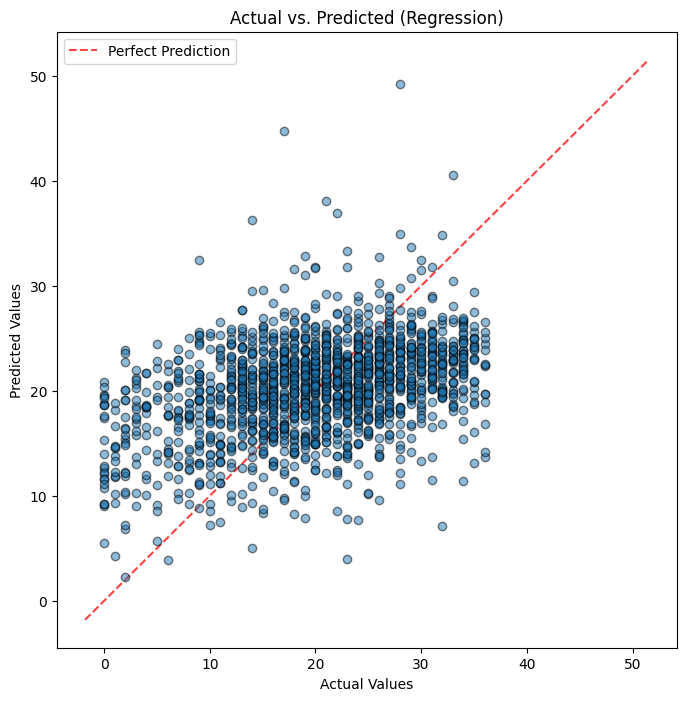

In [19]:
from src.evaluation import Evaluation

evaluation = Evaluation(prediction, actual)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()


In [20]:
# convert training and testing dataloader back to tensor
all_inputs_training = []

for a, b in training_dl:
    patient, visit, features = a.shape
    for p in range(patient):
        all_inputs_training.append(a[p])

training_tensor = torch.stack(all_inputs_training)

all_inputs_testing = []

for a, b in testing_dl:
    patient, visit, features = a.shape
    for p in range(patient):
        all_inputs_testing.append(a[p])

testing_tensor = torch.stack(all_inputs_testing)

NameError: name 'training_dl' is not defined

In [ ]:
print(training_tensor.shape)

torch.Size([1120, 1, 25])


In [ ]:
# Have to wrap the model to format the output so shap can use it (bit silly tho)

from torch import nn

class LSTMWrapper(nn.Module):
    def __init__(self, model, device):
        super().__init__()
        self.model = model
        self.device = device

    def forward(self, input_data):
        data = input_data.to(device=self.device, dtype=torch.float32)
        output = self.model(data)
        
        if isinstance(output, tuple):
            output = output[0]

        output = output.squeeze(-1)

        return output

In [ ]:
import shap
torch.backends.cudnn.enabled = False

device = torch.device("cpu")
model = model.to(device=device)
model_wrapper = LSTMWrapper(model, device)
model_wrapper.eval()


background_data = training_tensor[:].to(device=device)
data = testing_tensor[:].to(device=device)

explainer = shap.GradientExplainer(model_wrapper, background_data)
shap_values = explainer.shap_values(data)

In [ ]:
shap_values = shap_values.squeeze()
shap_values.shape

(280, 25)

/tmp/ipykernel_11000/2007217077.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, data.squeeze().cpu().numpy(), feature_names=dmo_features)


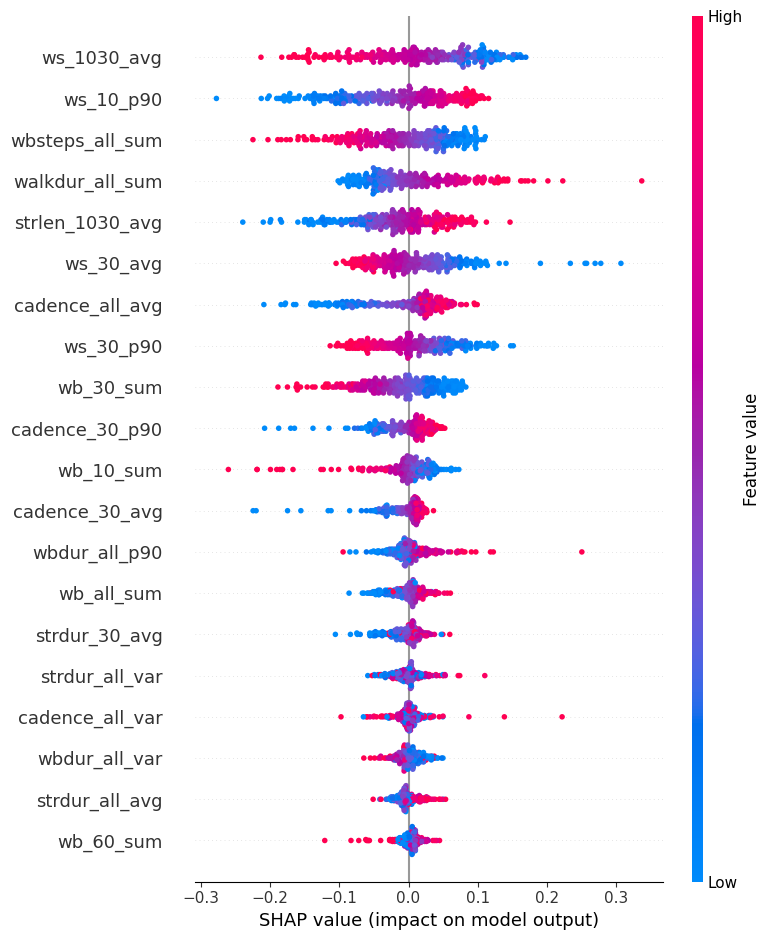

In [ ]:
shap.summary_plot(shap_values, data.squeeze().cpu().numpy(), feature_names=dmo_features)